🎉 熵坍缩神图已生成，保存至: micro_grammar_entropy.png


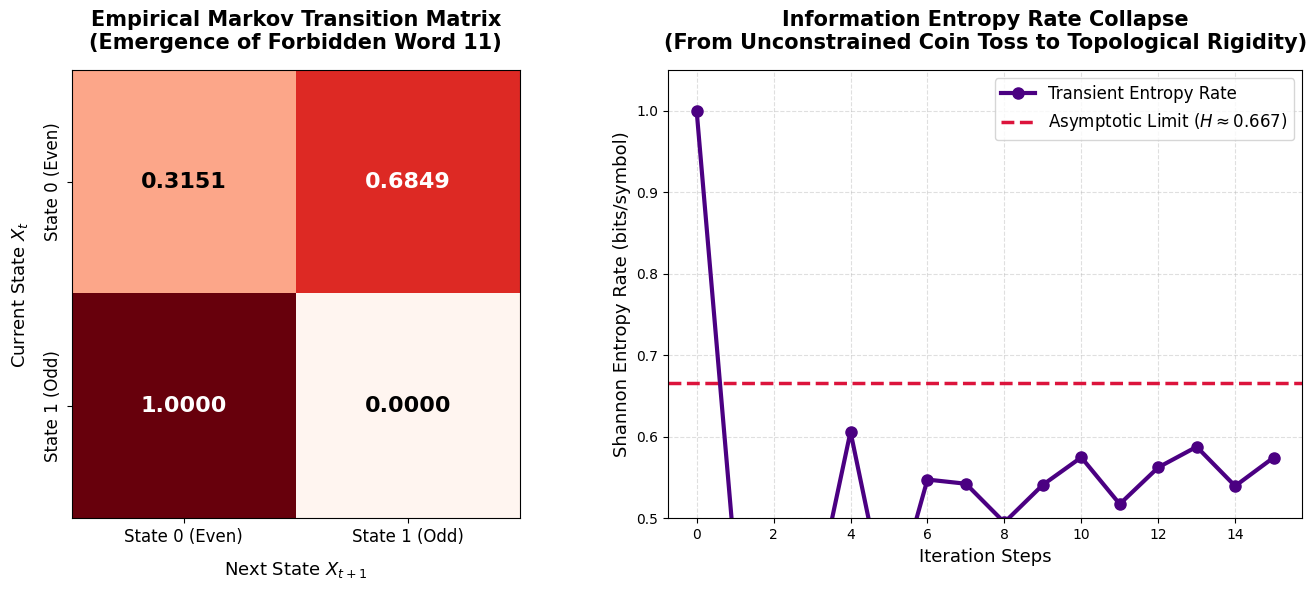

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 初始化系统参数
# ==========================================
mu = 1.7548776662466927
x_star = (np.sqrt(1 + 4*mu) - 1) / (2*mu)

# ==========================================
# 2. 实验 A: 构建经验马尔可夫转移矩阵
# ==========================================
N_matrix = 1000000
x_curr = np.random.uniform(-1, 1, N_matrix)
s_curr = (x_curr >= x_star).astype(int)

x_next = 1.0 - mu * x_curr**2
s_next = (x_next >= x_star).astype(int)

M = np.zeros((2, 2))
for i in range(2):
    mask = (s_curr == i)
    for j in range(2):
        M[i, j] = np.sum(s_next[mask] == j) / np.sum(mask)

# ==========================================
# 3. 实验 B: 香农熵率的动态坍缩
# ==========================================
steps = 15
N_ent = 500000
# 初始化：强行让状态 0 和 1 各占 50%，模拟无约束的纯随机抛硬币 (Entropy = 1.0)
x_ent = np.concatenate([np.random.uniform(-1, x_star, N_ent//2),
                        np.random.uniform(x_star, 1, N_ent//2)])

entropy_rate = [1.0] # 初始未受限状态的香农熵为 1.0 bit
for t in range(1, steps + 1):
    s_c = (x_ent >= x_star).astype(int)
    x_n = 1.0 - mu * x_ent**2
    s_n = (x_n >= x_star).astype(int)
    
    p0 = np.mean(s_c == 0)
    
    # 计算当前步的转移概率
    mask0 = (s_c == 0)
    p00 = np.mean(s_n[mask0] == 0)
    p01 = 1.0 - p00
    
    # 计算瞬态香农熵率 H(X_{t+1} | X_t)
    H_given_0 = 0.0
    if p00 > 0 and p01 > 0:
        H_given_0 = -p00 * np.log2(p00) - p01 * np.log2(p01)
    
    # 状态 1 必然转移到 0，所以 H(X_{t+1} | X_t=1) = 0
    H_t = p0 * H_given_0 
    entropy_rate.append(H_t)
    
    # 更新坐标
    x_ent = x_n

# ==========================================
# 4. 顶级学术图表绘制
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot A: 热力图
cax = axes[0].matshow(M, cmap='Reds', vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        text_color = 'white' if M[i, j] > 0.5 else 'black'
        # 特别高亮 P(1->1) 的绝对零值
        weight = 'heavy' if (i==1 and j==1) else 'bold'
        axes[0].text(j, i, f"{M[i, j]:.4f}", ha='center', va='center', 
                     color=text_color, fontsize=16, fontweight=weight)

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['State 0 (Even)', 'State 1 (Odd)'], fontsize=12)
axes[0].set_yticklabels(['State 0 (Even)', 'State 1 (Odd)'], fontsize=12, rotation=90, va='center')
axes[0].xaxis.set_ticks_position('bottom')
axes[0].set_xlabel("Next State $X_{t+1}$", fontsize=13, labelpad=10)
axes[0].set_ylabel("Current State $X_t$", fontsize=13, labelpad=10)
axes[0].set_title(r"Empirical Markov Transition Matrix" "\n" r"(Emergence of Forbidden Word 11)", fontsize=15, fontweight='bold', pad=15)

# Subplot B: 熵坍缩
axes[1].plot(range(steps + 1), entropy_rate, marker='o', color='#4B0082', linewidth=3, markersize=8, label='Transient Entropy Rate')
axes[1].axhline(y=2/3, color='#DC143C', linestyle='--', linewidth=2.5, label=r'Asymptotic Limit ($H \approx 0.667$)')

axes[1].set_title(r"Information Entropy Rate Collapse" "\n" r"(From Unconstrained Coin Toss to Topological Rigidity)", fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel("Iteration Steps", fontsize=13)
axes[1].set_ylabel("Shannon Entropy Rate (bits/symbol)", fontsize=13)
axes[1].set_xticks(range(0, steps + 1, 2))
axes[1].set_ylim(0.5, 1.05)
axes[1].legend(fontsize=12, loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
filename = 'micro_grammar_entropy.png'
plt.savefig(filename, dpi=300)
print(f"🎉 熵坍缩神图已生成，保存至: {filename}")
plt.show()